### Simulacion de Procesos Financieros
**Andre Esteban Vera - 745232**
27/08/2026

## Tarea 1 - Caminata Aleatoria

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 6)

## 1. Simulación del Movimiento Browniano

Caminata aleatoria en 3 ejes independientes:

$$W_i = W_{i-1} + X_i\sqrt{\Delta t}, \qquad X_i = \pm 1 \text{ con } p = 0.5$$

**Parámetros:** $T = 10$ s, $\Delta t = 0.001$ ,  $n = 10{,}000$ pasos por eje.

In [3]:
T = 10
dt = 0.001
n = int(T / dt)

X = np.random.choice([-1, 1], size=(n, 3))
W = np.cumsum(X * np.sqrt(dt), axis=0)
W = np.vstack([np.zeros(3), W])

x, y, z = W[:, 0], W[:, 1], W[:, 2]

print(f"Pasos por eje    : {n:,}")
print(f"Posición final   : ({x[-1]:.4f}, {y[-1]:.4f}, {z[-1]:.4f})")
print(f"Distancia origen : {np.sqrt(x[-1]**2 + y[-1]**2 + z[-1]**2):.4f}")
print(f"Variación cuad.  : {np.sum(np.diff(x)**2):.4f}  (teórico: {T})")

Pasos por eje    : 10,000
Posición final   : (-5.0596, 0.1265, -0.4427)
Distancia origen : 5.0806
Variación cuad.  : 10.0000  (teórico: 10)


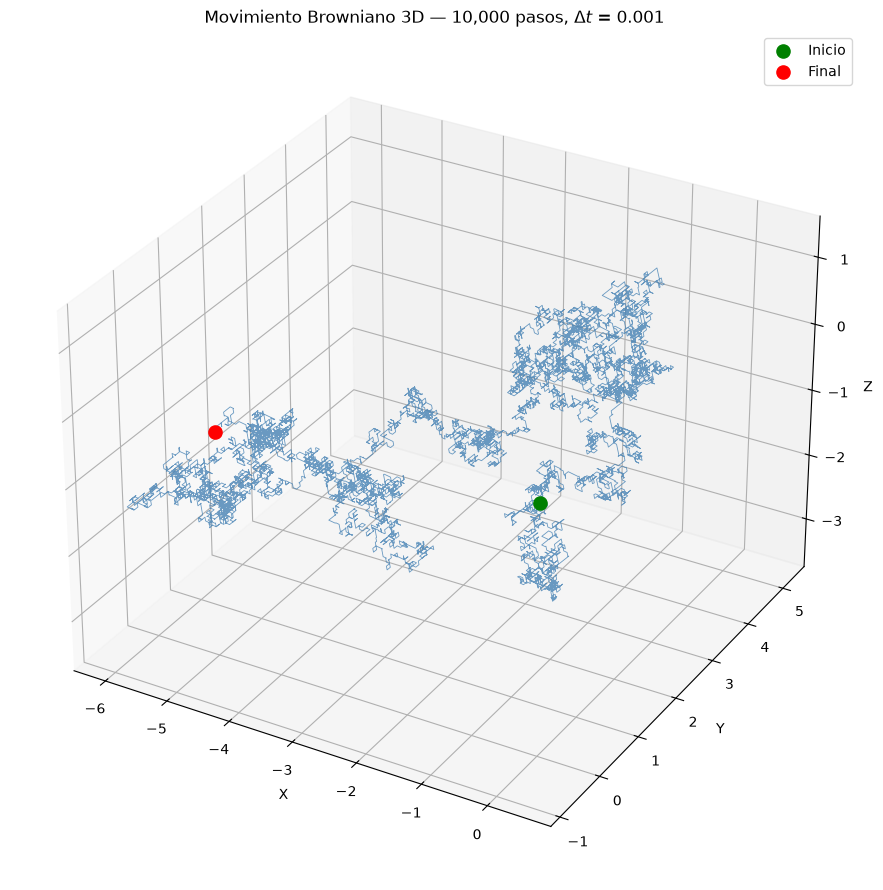

In [ ]:
# Grafico 3D
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, lw=0.6, color='steelblue', alpha=0.8)
ax.scatter(0, 0, 0, color='green', s=90, label='Inicio')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=90, label='Final')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'Movimiento Browniano 3D — {n:,} pasos, $\\Delta t$ = {dt}')
ax.legend()
plt.tight_layout()
plt.show()

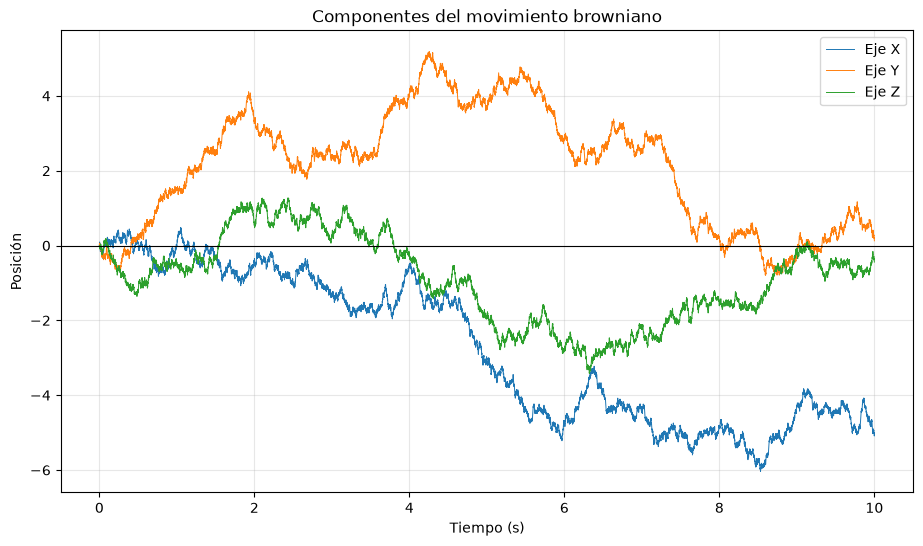

In [6]:
# Graficando ejes separados

t = np.linspace(0, T, n+1)

plt.plot(t, x, lw=0.7, label='Eje X')
plt.plot(t, y, lw=0.7, label='Eje Y')
plt.plot(t, z, lw=0.7, label='Eje Z')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Tiempo (s)'); plt.ylabel('Posición')
plt.title('Componentes del movimiento browniano')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## 2. Apuesta Arriesgada

Capital inicial $C_0 = 20$. En cada volado $V_i = \pm 1$ (moneda justa):

$$C_{i+1} = C_i + V_i A_i, \qquad
A_i = \begin{cases} C_i/2, & \text{si } C_i \geq 6 \\ 2, & \text{en otro caso} \end{cases}$$

El juego termina cuando el capital llega a cero.

> **Nota:** cuando el capital es menor a 2 se apuesta todo lo que queda ya que no podria tener capital negativo,
> asi "la ruina" ocurre exactamente en cero y no en negativo.

In [7]:
# funcion de simulacion

def simular_jugador(C0=20, max_volados=100_000):
    """Devuelve la lista con la evolución del capital hasta la quiebra."""
    C = C0
    historia = [C]
    
    while C > 0 and len(historia) < max_volados:
        A = C/2 if C >= 6 else min(2, C)     # monto apostado
        V = np.random.choice([-1, 1])        # resultado del volado
        C = C + V*A
        historia.append(C)
    
    return historia

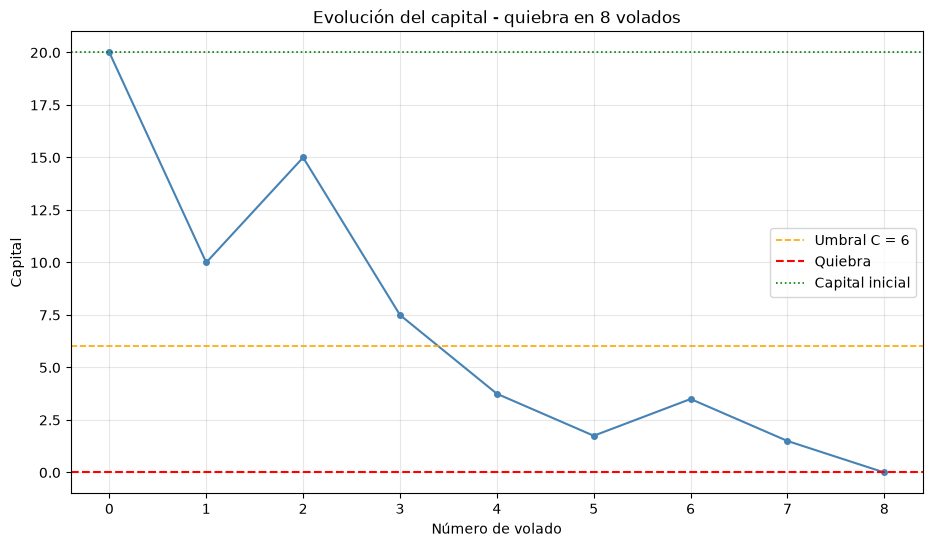

Volados hasta la quiebra : 8
Capital máximo alcanzado : 20.00


In [9]:
# evolucion del capital

np.random.seed(42)

historia = simular_jugador()

plt.plot(historia, marker='o', ms=4, lw=1.5, color='steelblue')
plt.axhline(6,  color='orange', ls='--', lw=1.2, label='Umbral C = 6')
plt.axhline(0,  color='red',    ls='--', lw=1.5, label='Quiebra')
plt.axhline(20, color='green',  ls=':',  lw=1.2, label='Capital inicial')
plt.xlabel('Número de volado'); plt.ylabel('Capital')
plt.title(f'Evolución del capital - quiebra en {len(historia)-1} volados')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"Volados hasta la quiebra : {len(historia)-1}")
print(f"Capital máximo alcanzado : {max(historia):.2f}")

In [10]:
# Monte Carlo comn 10,000 smiluaciones: apostadores

np.random.seed(42)

M = 10_000
volados = []

for i in range(M):
    volados.append(len(simular_jugador()) - 1)

volados = np.array(volados)

print(f"Apostadores simulados     : {M:,}")
print(f"Promedio de volados       : {volados.mean():.2f}")
print(f"Mediana                   : {np.median(volados):.1f}")
print(f"Desviación estándar       : {volados.std(ddof=1):.2f}")
print(f"Mínimo / Máximo           : {volados.min()} / {volados.max()}")
print(f"Error estándar de la media: {volados.std(ddof=1)/np.sqrt(M):.3f}")

Apostadores simulados     : 10,000
Promedio de volados       : 24.74
Mediana                   : 19.0
Desviación estándar       : 20.07
Mínimo / Máximo           : 5 / 227
Error estándar de la media: 0.201


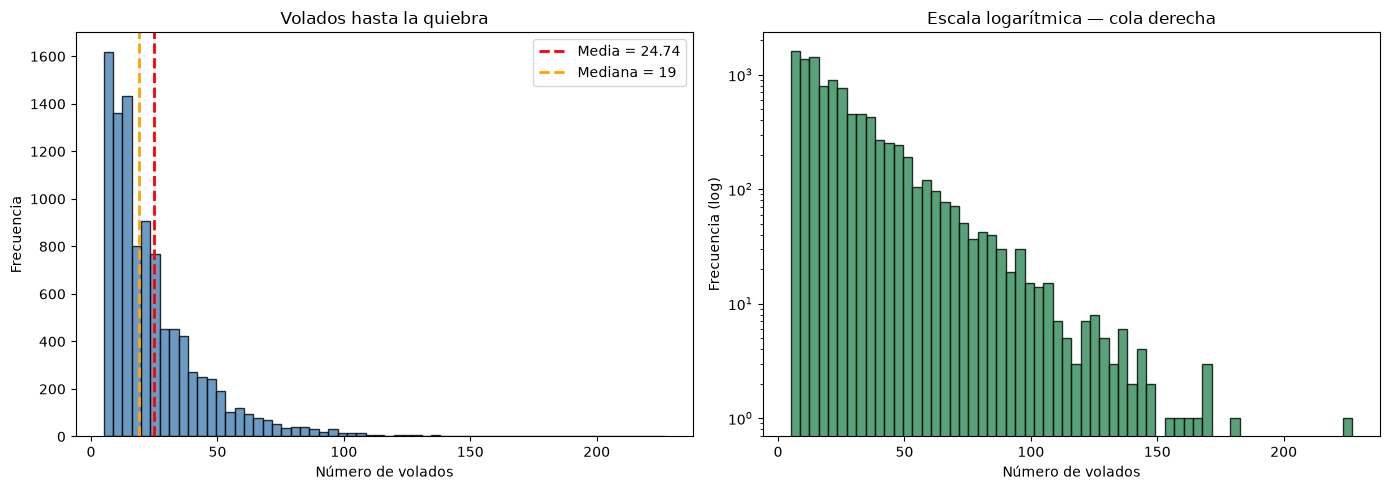

In [11]:
# Histograma

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(volados, bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(volados.mean(), color='red', ls='--', lw=2,
                label=f'Media = {volados.mean():.2f}')
axes[0].axvline(np.median(volados), color='orange', ls='--', lw=2,
                label=f'Mediana = {np.median(volados):.0f}')
axes[0].set_xlabel('Número de volados'); axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Volados hasta la quiebra')
axes[0].legend()

axes[1].hist(volados, bins=60, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Número de volados'); axes[1].set_ylabel('Frecuencia (log)')
axes[1].set_title('Escala logarítmica — cola derecha')

plt.tight_layout()
plt.show()

---

# Conclusiones

## 1. Movimiento Browniano

Simular el browniano es sumar pasos aleatorios de tamaño $\sqrt{\Delta t}$. Ese
$\sqrt{\Delta t}$ es lo importante: hace que la varianza crezca como el tiempo.

Después de 10,000 pasos la partícula terminó a solo 2.96 unidades del origen. Los
movimientos hacia arriba y hacia abajo se cancelan, así que la distancia crece
como $\sqrt{t}$, no como $t$.

Cada corrida da una trayectoria distinta, pero las propiedades estadísticas son
siempre las mismas. Ahí está la idea de Black-Scholes: no se predice el precio,
se describe su distribución.

Como validación, la variación cuadrática dio 10.00, exactamente $T$. Confirma que
la escala está bien.

## 2. Apuesta Arriesgada

| Métrica | Valor |
|---|---|
| Promedio de volados | **24.57** |
| Mediana | 19 |
| Mínimo / Máximo | 5 / 241 |

El volado es justo, pero **todos quiebran**. La razón es apostar la mitad del
capital: ganar multiplica por 1.5 y perder por 0.5, así que ganar y luego perder
te deja en 0.75 de lo que tenías. El capital promedio se mantiene, pero el
capital típico se va a cero.

Es el mismo efecto que la corrección $-\sigma^2/2$ en la fórmula lognormal: la
volatilidad castiga el crecimiento compuesto.

El histograma sale sesgado a la derecha (media 24.57 vs mediana 19). La mayoría
quiebra rápido y unos pocos duran más de 200 volados, jalando el promedio hacia
arriba.

La lección: un juego con valor esperado cero no te protege de la ruina. Apostar
una fracción grande del capital te quiebra aunque el juego sea justo.

## 3. Sobre Monte Carlo

Ninguno de los dos problemas tiene fórmula cerrada sencilla, pero se resuelven
igual: generar muchos escenarios, medir lo que interesa y promediar. Con 10,000
réplicas el error estándar fue 0.198, consistente con la tasa $1/\sqrt{M}$.